In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

In [2]:
# loading dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Check Duplicate Rows
df.duplicated().sum()

0

In [8]:
# Convert TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing Value
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# Handle the misssing value
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)
# Check missing value after handle
df.isnull().sum().sum()

C:\Users\nimis\AppData\Local\Temp\ipykernel_21056\654087241.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


0

In [10]:
# Drop customerID
df.drop(columns=["customerID"],inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [11]:
#Target Variable Distribution
# YES: Customer left the company
# No: Customer stayed
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

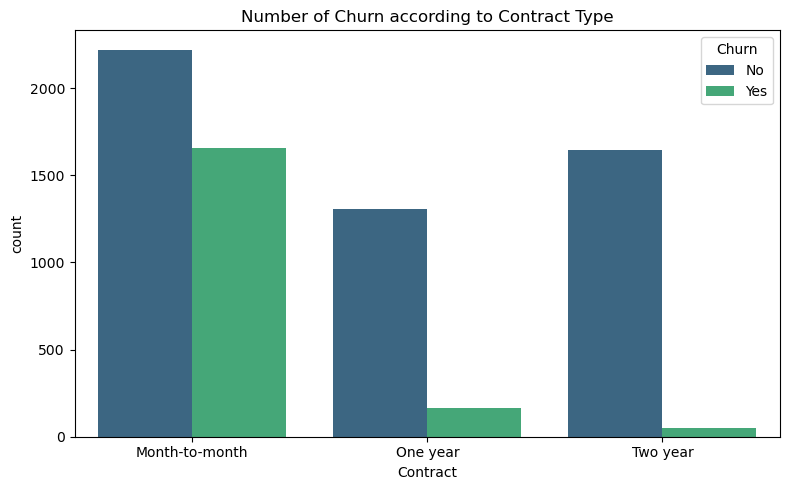

In [12]:
#Plot 1: Churn distribution according to Contract Type  (bar chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Number of Churn according to Contract Type')
plt.tight_layout()
plt.show()

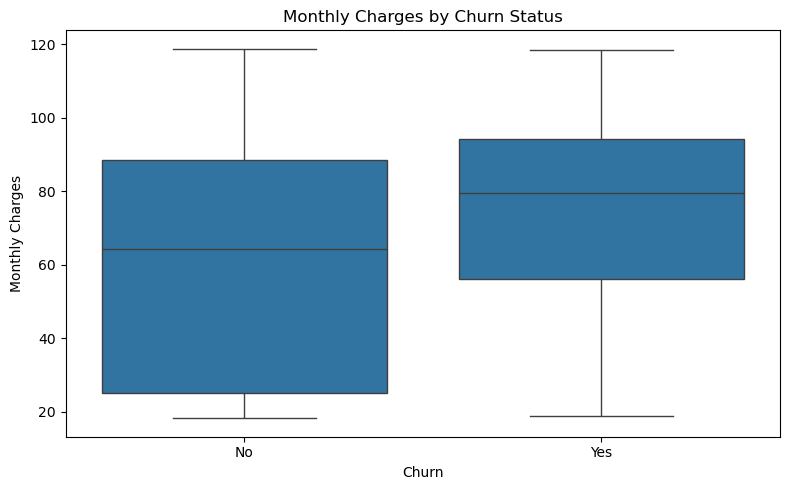

In [13]:
# Plot 2: Monthly Charges by Churn status (box plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

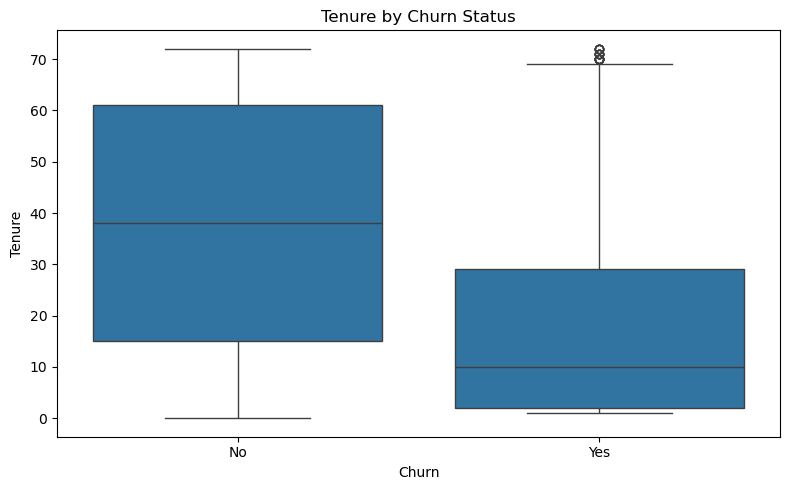

In [14]:
# Plot 3 : Tenure by Churn status (box plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.tight_layout()
plt.show()

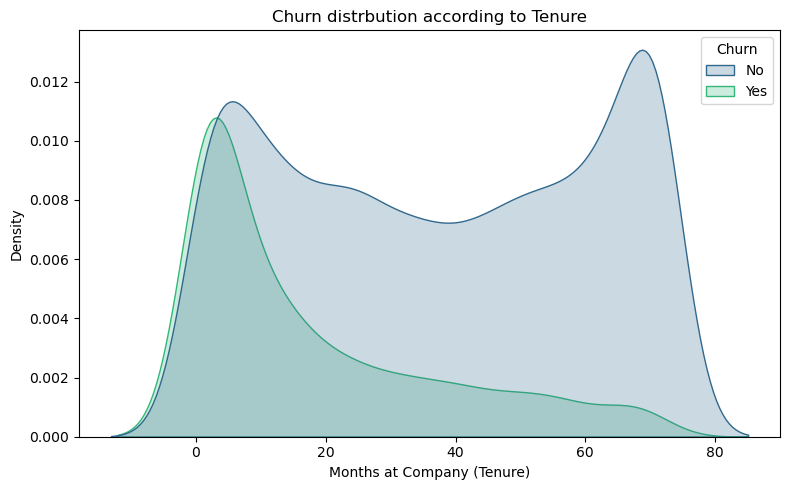

In [15]:
# Plot 4: Churn distribution by tenure (histogram)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, palette='viridis')
#ax = sns.histplot(data=df, x="tenure", hue="Churn", kde=True, palette={"No": "steelblue", "Yes": "tomato"})
plt.title('Churn distrbution according to Tenure')
plt.xlabel('Months at Company (Tenure)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

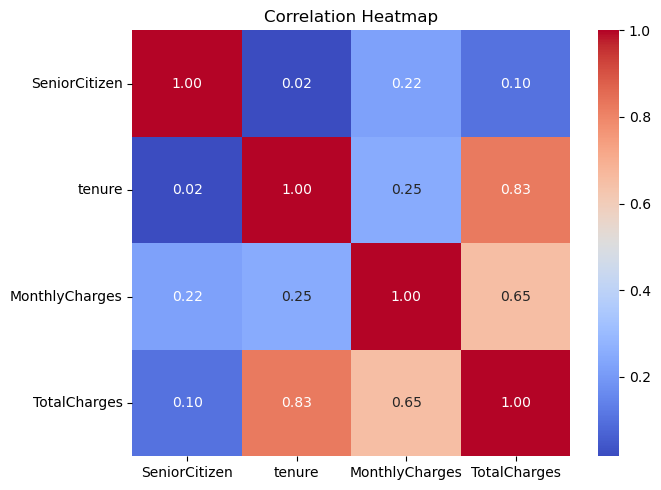

In [16]:
# Plot 4: Correlation heatmap
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
# Encode TARGET column: Churn (Yes → 1, No → 0) 
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("\nTarget encoded. Churn (1=Yes, 0=No):", df["Churn"].value_counts().to_dict())


Target encoded. Churn (1=Yes, 0=No): {0: 5174, 1: 1869}


In [18]:
# Identify categorical and numerical columns 
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_cols.remove("Churn") 

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Feature Engineering & Encoding

In [19]:

 # Encode categorical columns  # Converts text/categorical values → numbers
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
# Separate features (X) and target (y) 
X = df.drop(columns=["Churn"])   # all columns except Churn
y = df["Churn"]                  # only Churn column
 
print("\nFeatures shape:", X.shape)
print("Target shape  :", y.shape)


Features shape: (7043, 20)
Target shape  : (7043,)


In [21]:
# Train Model 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # Medium dataset
 
print(f"\nTrain size: {X_train.shape[0]} rows")
print(f"Test size : {X_test.shape[0]} rows")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



Train size: 5634 rows
Test size : 1409 rows


In [22]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print(classification_report(y_test,lr_preds))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [23]:
# Model 2: XGBoost
xgb = XGBClassifier(
    n_estimators=300,   
    max_depth=4,        
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3, 
    random_state=42
)

xgb.fit(X_train,y_train)
xgb_preds = xgb.predict(X_test)
print(classification_report(y_test,xgb_preds))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [24]:
# Model 3: RandomForest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)
rf_preds = rf.predict(X_test)
print(classification_report(y_test,rf_preds))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [25]:
# Model Comparison
models = {
    'Logistic Regression': lr_preds,
    'Random Forest':       rf_preds,
    'XGBoost':             xgb_preds
}

# Build comparison table
results = []
for model_name, preds in models.items():
    results.append({
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
        'F1 Score':  f1_score(y_test, preds)
    })

# Show as DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1 Score', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2              XGBoost  0.753726   0.523894  0.791444  0.630458
0  Logistic Regression  0.796309   0.635514  0.545455  0.587050
1        Random Forest  0.790632   0.638596  0.486631  0.552352


In [31]:
# Find Best model
best_model_name = results_df.iloc[0]['Model']
best_f1         = results_df.iloc[0]['F1 Score']
print(f"\nBest Model : {best_model_name}")
print(f"Best F1: {best_f1:.4f}")


Best Model : XGBoost
Best F1: 0.6305


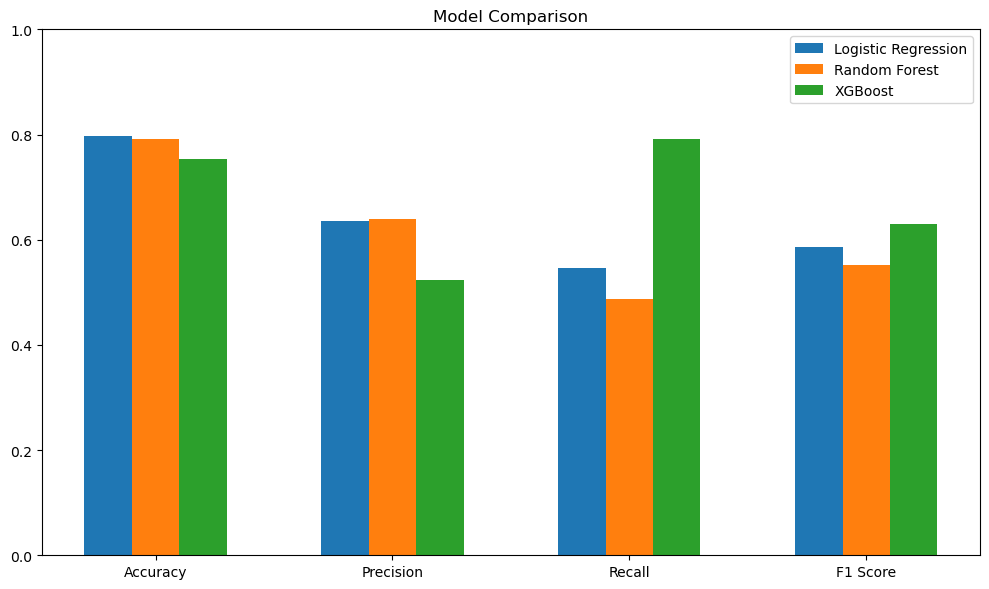

In [34]:
# Plot model comparison
metrics = ['Accuracy', 'Precision', 'Recall','F1 Score']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model_name, preds) in enumerate(models.items()):
    scores = [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds)
    ]
    ax.bar(x + i * width, scores, width, label=model_name)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Model Comparison')
plt.tight_layout()
plt.show()

In [27]:
# Step 1 — Predict on test data
xgb_preds = xgb.predict(X_test_scaled)

# Step 2 — Get probability scores
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]

# Step 3 — Build result dataframe
churn_results = pd.DataFrame({
    'CustomerID':      df.loc[X_test.index, 'customerID'],
    'Actual Churn':    y_test.values,
    'Predicted Churn': xgb_preds,
    'Churn Probability': xgb_proba
})

# Step 4 — Filter only predicted churners
churned_customers = churn_results[
    churn_results['Predicted Churn'] == 1
].sort_values('Churn Probability', ascending=False)

print(churned_customers)


      CustomerID  Actual Churn  Predicted Churn  Churn Probability
3512        4835             0                1           0.605723
2860        1680             0                1           0.597739
6244        3791             0                1           0.582170
4473        1827             0                1           0.582170
1088        5003             1                1           0.582170
...          ...           ...              ...                ...
3792        4769             1                1           0.501226
352         2887             0                1           0.501226
2457        3689             0                1           0.501004
1439         340             1                1           0.500533
3043        2572             1                1           0.500533

[118 rows x 4 columns]


In [35]:
 print(classification_report(y_test, xgb_preds,
                             target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.76      0.95      0.84      1035
       Churn       0.53      0.17      0.25       374

    accuracy                           0.74      1409
   macro avg       0.64      0.56      0.55      1409
weighted avg       0.70      0.74      0.69      1409



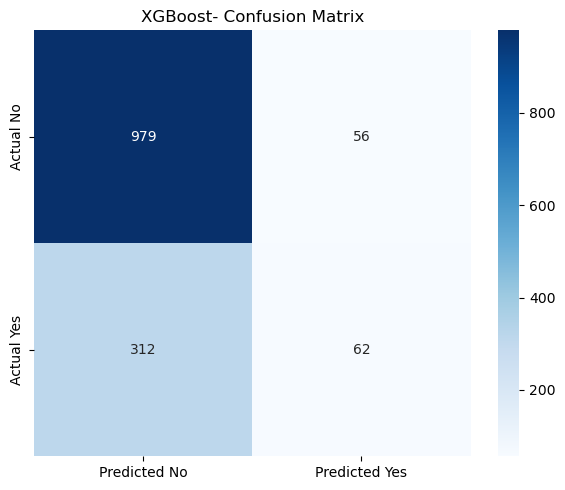

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.show()

Feature Importance

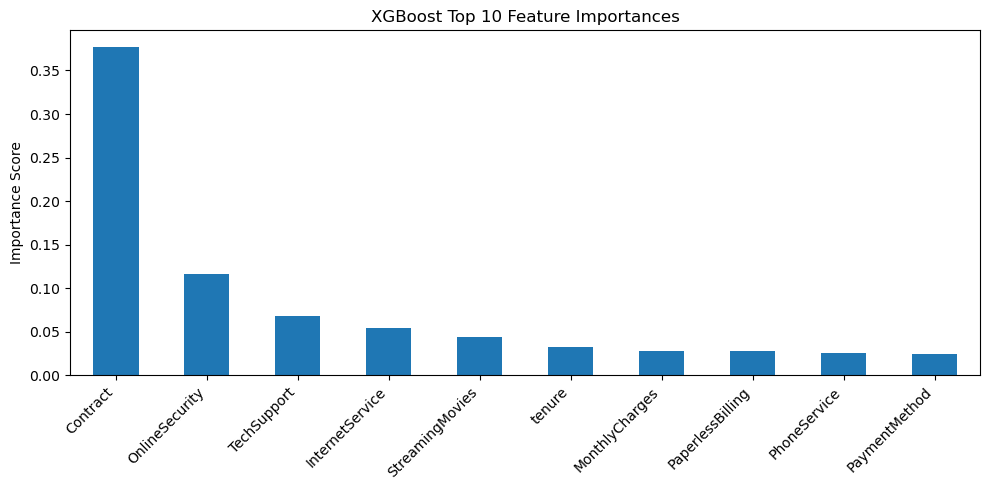

In [41]:
feat_imp = pd.Series(xgb.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
 
plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind='bar')
plt.title('XGBoost Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Predict Churn Customer

In [42]:
# Get original test indices
test_indices = X_test.index
 
# Predict probabilities
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]
 
# Re-load original data to get customerID
df_original = pd.read_csv("Telco-Customer-Churn.csv")
 
churn_results = pd.DataFrame({
    'CustomerID'        : df_original.loc[test_indices, 'customerID'].values,
    'Actual Churn'      : y_test.values,
    'Predicted Churn'   : xgb_preds,
    'Churn Probability' : np.round(xgb_proba, 4)
})
 
# Add risk level
def risk_level(prob):
    if prob >= 0.80:   return 'High Risk'
    elif prob >= 0.50: return 'Medium Risk'
    else:              return 'Low Risk'
 
churn_results['Risk Level'] = churn_results['Churn Probability'].apply(risk_level)
 
# Filter only predicted churners
predicted_churners = churn_results[
    churn_results['Predicted Churn'] == 1
].sort_values('Churn Probability', ascending=False).reset_index(drop=True)
 
print(f"\n   Total predicted churners : {len(predicted_churners)}")
print(f"\n   Risk breakdown:")
print(predicted_churners['Risk Level'].value_counts().to_string())
 
print(f"\n   Top 10 High-Risk Customers:")
print(predicted_churners.head(10).to_string(index=False))


   Total predicted churners : 118

   Risk breakdown:
Risk Level
🟡 Medium Risk    118

   Top 10 High-Risk Customers:
CustomerID  Actual Churn  Predicted Churn  Churn Probability    Risk Level
6814-ZPWFQ             0                1             0.6057 🟡 Medium Risk
2452-KDRRH             0                1             0.5977 🟡 Medium Risk
5331-RGMTT             0                1             0.5822 🟡 Medium Risk
2665-NPTGL             0                1             0.5822 🟡 Medium Risk
7029-RPUAV             1                1             0.5822 🟡 Medium Risk
1751-NCDLI             0                1             0.5822 🟡 Medium Risk
8884-ADFVN             1                1             0.5822 🟡 Medium Risk
6861-XWTWQ             1                1             0.5822 🟡 Medium Risk
6661-HBGWL             1                1             0.5767 🟡 Medium Risk
8818-DOPVL             0                1             0.5767 🟡 Medium Risk
